<a href="https://colab.research.google.com/github/Dhanush7-tech/Deep-Learning-LAB/blob/main/LAB-2/DeepLearning_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%matplotlib inline

Dataset Summary
----------------------------------------
Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing images shape  : (10000, 28, 28)
Testing labels shape  : (10000,)
Number of classes     : 10
Image size            : 28 x 28
Pixel value range     : 0 to 255


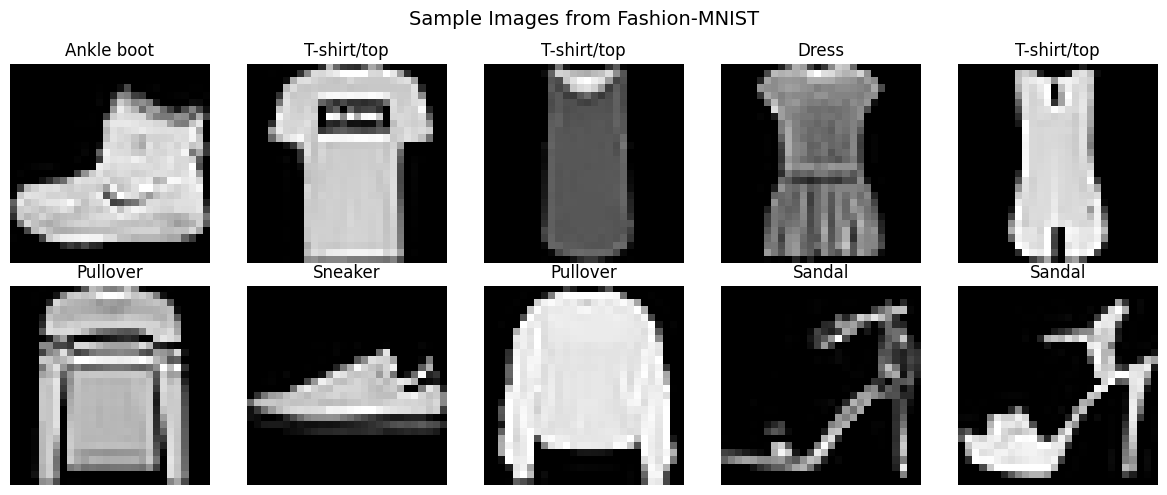

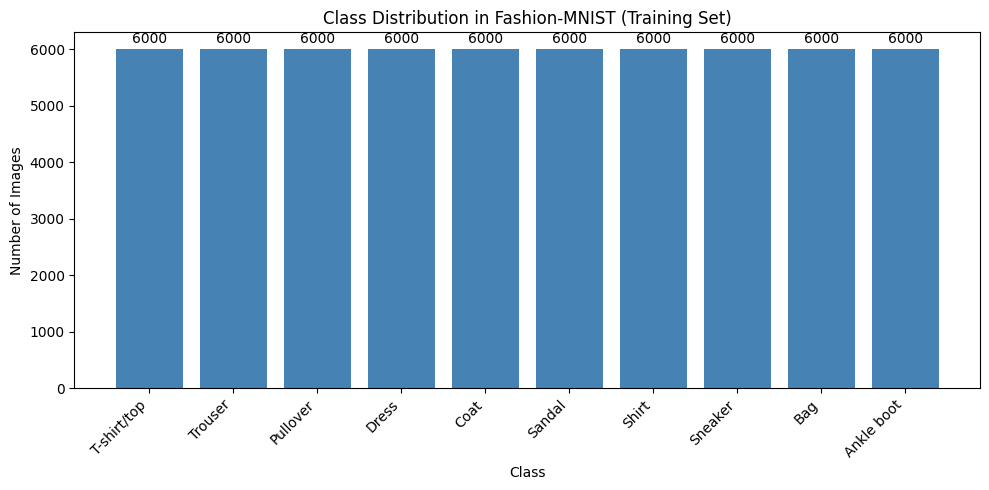

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Dataset Summary")
print("-" * 40)
print(f"Training images shape : {x_train.shape}")
print(f"Training labels shape : {y_train.shape}")
print(f"Testing images shape  : {x_test.shape}")
print(f"Testing labels shape  : {y_test.shape}")
print(f"Number of classes     : {len(np.unique(y_train))}")
print(f"Image size            : {x_train.shape[1]} x {x_train.shape[2]}")
print(f"Pixel value range     : {x_train.min()} to {x_train.max()}")


plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Images from Fashion-MNIST", fontsize=14)
plt.tight_layout()
plt.show()


unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
bars = plt.bar([class_names[u] for u in unique], counts, color='steelblue')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Fashion-MNIST (Training Set)")
plt.xticks(rotation=45, ha='right')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
              str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

# Load data (skip if already loaded from Task 1)
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# ---- BEFORE preprocessing ----
print("Shapes BEFORE preprocessing")
print("-" * 40)
print(f"x_train shape : {x_train.shape}")
print(f"x_test shape  : {x_test.shape}")
print(f"Data type     : {x_train.dtype}")
print(f"Pixel range   : {x_train.min()} to {x_train.max()}")

#  Flatten images: 28x28 -> 784
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

#  Normalize pixel values: 0-255 -> 0-1
x_train_norm = x_train_flat.astype('float32') / 255.0
x_test_norm = x_test_flat.astype('float32') / 255.0
#AFTER preprocessing
print("\nShapes AFTER preprocessing")
print("-" * 40)
print(f"x_train shape : {x_train_norm.shape}")
print(f"x_test shape  : {x_test_norm.shape}")
print(f"Data type     : {x_train_norm.dtype}")
print(f"Pixel range   : {x_train_norm.min()} to {x_train_norm.max()}")

print("\nSanity Check")
print("-" * 40)
print(f"Original pixel example (0-255): {x_train[0][10][10]}")
print(f"Normalized pixel example (0-1): {x_train_norm[0].reshape(28,28)[10][10]:.4f}")

Shapes BEFORE preprocessing
----------------------------------------
x_train shape : (60000, 28, 28)
x_test shape  : (10000, 28, 28)
Data type     : uint8
Pixel range   : 0 to 255

Shapes AFTER preprocessing
----------------------------------------
x_train shape : (60000, 784)
x_test shape  : (10000, 784)
Data type     : float32
Pixel range   : 0.0 to 1.0

Sanity Check
----------------------------------------
Original pixel example (0-255): 0
Normalized pixel example (0-1): 0.0000


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ---- One-hot encode labels ----
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Label shape before encoding:", y_train.shape)
print("Label shape after encoding :", y_train_cat.shape)

#Compile the model
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train_norm, y_train_cat,
    validation_data=(x_test_norm, y_test_cat),
    epochs=20,
    batch_size=32,
    verbose=1
)

Label shape before encoding: (60000,)
Label shape after encoding : (60000, 10)
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8226 - loss: 0.4947 - val_accuracy: 0.8407 - val_loss: 0.4399
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8665 - loss: 0.3666 - val_accuracy: 0.8526 - val_loss: 0.4020
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8779 - loss: 0.3312 - val_accuracy: 0.8650 - val_loss: 0.3714
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8849 - loss: 0.3099 - val_accuracy: 0.8637 - val_loss: 0.3655
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8913 - loss: 0.2910 - val_accuracy: 0.8789 - val_loss: 0.3443
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8959 - loss: 0.2785 - val_accuracy: 0.8706 - val_loss: 0.3508
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9010 - loss: 0.2658 - val_accuracy: 0.8793 - val_loss: 0.3384
Epoch 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Evaluation Metrics
----------------------------------------
Accuracy  : 0.8852
Precision : 0.8858
Recall    : 0.8852
F1-Score  : 0.8854

Classification Report
----------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.83      0.84      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.80      0.77      0.78      1000
       Dress       0.90      0.90      0.90      1000
        Coat       0.78      0.82      0.80      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.69      0.70      0.70      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.99      0.96      0.98      1000
  Ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



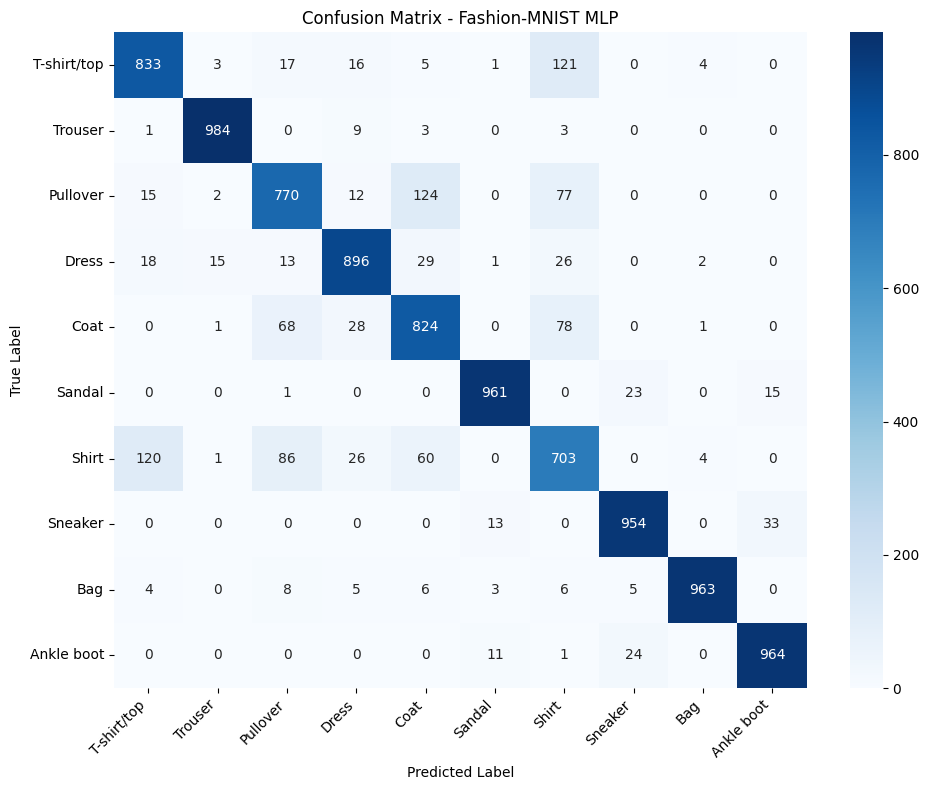

In [ ]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Get predictions ----
y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Evaluation Metrics")
print("-" * 40)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nClassification Report")
print("-" * 40)
print(classification_report(y_true, y_pred, target_names=class_names))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fashion-MNIST MLP")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#--TASK-7

In [ ]:
!pip install scikeras --quiet

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

baseline_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

baseline_history = baseline_model.fit(
    x_train_norm, y_train,
    validation_data=(x_test_norm, y_test),
    epochs=10, batch_size=32, verbose=1
)

baseline_loss, baseline_acc = baseline_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nBaseline Test Accuracy: {baseline_acc:.4f}")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8268 - loss: 0.4878 - val_accuracy: 0.8457 - val_loss: 0.4259
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8668 - loss: 0.3637 - val_accuracy: 0.8609 - val_loss: 0.3896
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8769 - loss: 0.3327 - val_accuracy: 0.8560 - val_loss: 0.3968
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8870 - loss: 0.3085 - val_accuracy: 0.8712 - val_loss: 0.3577
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8905 - loss: 0.2906 - val_accuracy: 0.8704 - val_loss: 0.3585
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8961 - loss: 0.2798 - val_accuracy: 0.8817 - val_loss: 0.3285
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9018 - loss: 0.2637 - val_accuracy: 0.8749 - val_loss: 0.3536
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9040 - loss: 0.2

In [ ]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

def build_model(n_hidden=1, n_neurons=128, learning_rate=0.001,
                 optimizer_name='adam', activation='relu', dropout_rate=0.0,
                 meta=None):
    n_features_in = meta["n_features_in_"]
    n_classes = meta["n_classes_"]

    model = Sequential()
    model.add(Input(shape=(n_features_in,)))
    for _ in range(n_hidden):
        model.add(Dense(n_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(n_classes, activation='softmax'))

    if optimizer_name == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

clf = KerasClassifier(
    model=build_model,
    verbose=0,
    n_hidden=1,
    n_neurons=128,
    learning_rate=0.001,
    optimizer_name='adam',
    activation='relu',
    dropout_rate=0.0,
    epochs=10,
    batch_size=32
)

param_distributions = {
    'model__n_hidden': [1, 2, 3],
    'model__n_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'model__optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5]
}

print("Search space defined:")
for k, v in param_distributions.items():
    print(f"  {k}: {v}")

Search space defined:
  model__n_hidden: [1, 2, 3]
  model__n_neurons: [32, 64, 128, 256]
  model__learning_rate: [0.1, 0.01, 0.001]
  batch_size: [16, 32, 64, 128]
  epochs: [10, 20, 30]
  model__optimizer_name: ['sgd', 'adam', 'rmsprop']
  model__activation: ['relu', 'tanh', 'sigmoid']
  model__dropout_rate: [0.0, 0.2, 0.5]


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


np.random.seed(42)
subset_idx = np.random.choice(len(x_train_norm), 6000, replace=False)
x_search = x_train_norm[subset_idx]
y_search = y_train[subset_idx]

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=15,          # number of random combinations to try
    cv=5,
    verbose=2,
    n_jobs=1,
    random_state=42
)

random_search_result = random_search.fit(x_search, y_search)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__learning_rate=0.1, model__n_hidden=3, model__n_neurons=256, model__optimizer_name=adam; total time=  16.4s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__learning_rate=0.1, model__n_hidden=3, model__n_neurons=256, model__optimizer_name=adam; total time=  17.4s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__learning_rate=0.1, model__n_hidden=3, model__n_neurons=256, model__optimizer_name=adam; total time=  16.1s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__learning_rate=0.1, model__n_hidden=3, model__n_neurons=256, model__optimizer_name=adam; total time=  16.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__learning_rate=0.1, model__n_hidden=3, model__n_neurons=2

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
print("Best Hyperparameters Found")
print("-" * 40)
for param, value in random_search_result.best_params_.items():
    print(f"{param}: {value}")

print(f"\nBest CV Accuracy: {random_search_result.best_score_:.4f}")

Best Hyperparameters Found
----------------------------------------
model__optimizer_name: rmsprop
model__n_neurons: 32
model__n_hidden: 3
model__learning_rate: 0.001
model__dropout_rate: 0.2
model__activation: tanh
epochs: 30
batch_size: 32

Best CV Accuracy: 0.8375


In [ ]:
best_params = random_search_result.best_params_

optimized_clf = KerasClassifier(
    model=build_model,
    verbose=1,
    model__n_hidden=best_params['model__n_hidden'],
    model__n_neurons=best_params['model__n_neurons'],
    model__learning_rate=best_params['model__learning_rate'],
    model__optimizer_name=best_params['model__optimizer_name'],
    model__activation=best_params['model__activation'],
    model__dropout_rate=best_params['model__dropout_rate'],
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size']
)

# Retrain on full training set
optimized_clf.fit(x_train_norm, y_train)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7622 - loss: 0.6827
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8223 - loss: 0.5171
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8342 - loss: 0.4847
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8405 - loss: 0.4624
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8439 - loss: 0.4519
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8496 - loss: 0.4399
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8535 - loss: 0.4307
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8559 - loss: 0.4243
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8559 - loss: 0.4197
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8572 - loss: 0.4175
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8592 - loss: 0.4113
Epoch 12/30
1875/1875 ━━━━━━━━

KerasClassifier(
	model=<function build_model at 0x7843d6d34a40>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=30
	model__n_hidden=3
	model__n_neurons=32
	model__learning_rate=0.001
	model__optimizer_name=rmsprop
	model__activation=tanh
	model__dropout_rate=0.2
	class_weight=None
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Optimized Model - Test Set Evaluation
----------------------------------------
Accuracy  : 0.8650
Precision : 0.8657
Recall    : 0.8650
F1-Score  : 0.8650

Classification Report
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.83      0.82      1000
     Trouser       0.98      0.97      0.97      1000
    Pullover       0.75      0.77      0.76      1000
       Dress       0.88      0.84      0.86      1000
        Coat       0.73      0.79      0.76      1000
      Sandal       0.97      0.93      0.95      1000
       Shirt       0.69      0.64      0.67      1000
     Sneaker       0.92      0.96      0.94      1000
         Bag       0.96      0.96      0.96      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



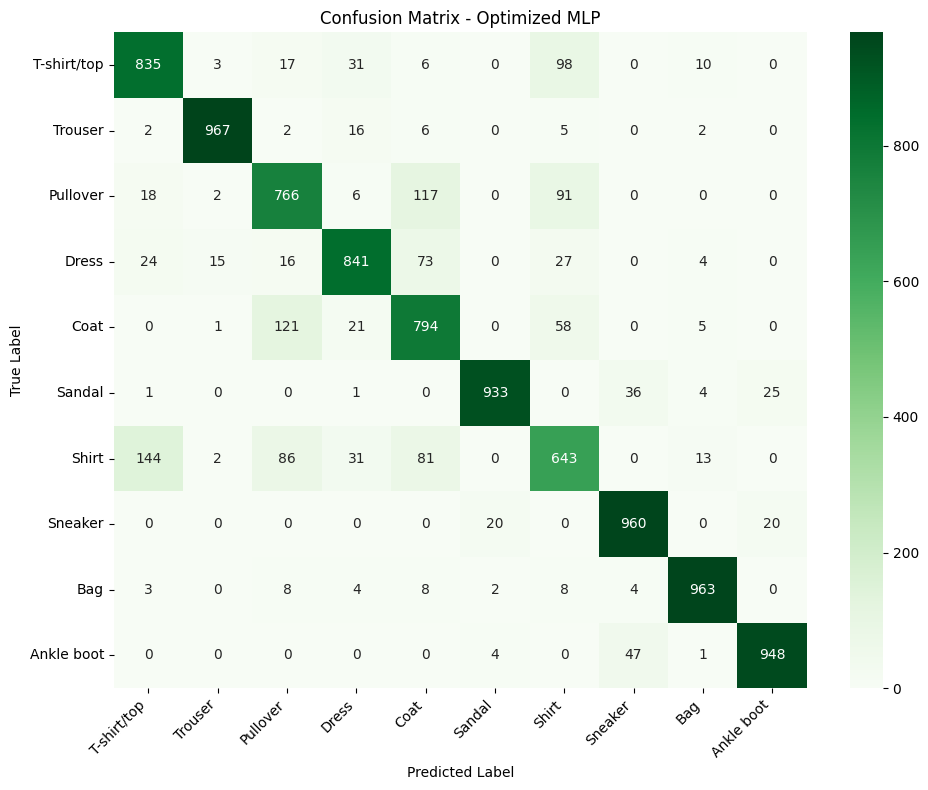

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_optimized = optimized_clf.predict(x_test_norm)

opt_acc = accuracy_score(y_test, y_pred_optimized)
opt_precision = precision_score(y_test, y_pred_optimized, average='weighted')
opt_recall = recall_score(y_test, y_pred_optimized, average='weighted')
opt_f1 = f1_score(y_test, y_pred_optimized, average='weighted')

print("Optimized Model - Test Set Evaluation")
print("-" * 40)
print(f"Accuracy  : {opt_acc:.4f}")
print(f"Precision : {opt_precision:.4f}")
print(f"Recall    : {opt_recall:.4f}")
print(f"F1-Score  : {opt_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_optimized, target_names=class_names))

cm_opt = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Optimized MLP")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Model Comparison
----------------------------------------
        Model  Accuracy  Precision  Recall  F1-Score
 Baseline MLP    0.8798   0.885843  0.8852  0.885412
Optimized MLP    0.8650   0.865683  0.8650  0.864958


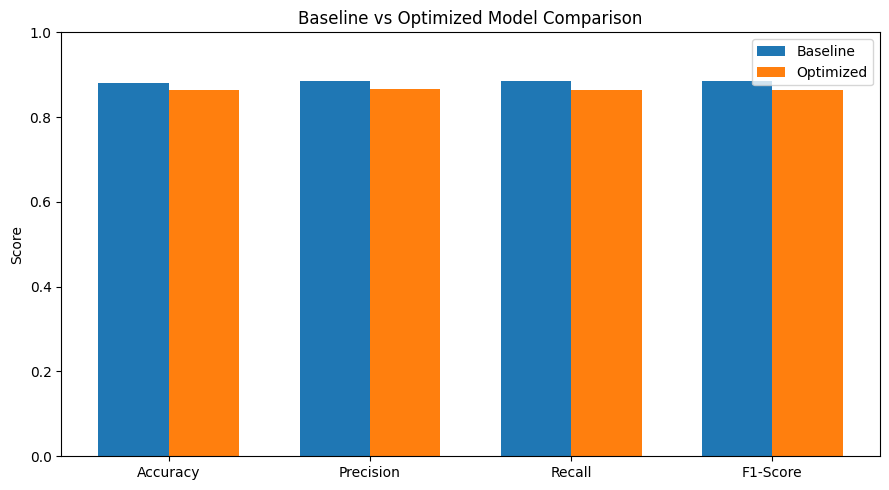

In [ ]:
comparison = {
    "Model": ["Baseline MLP", "Optimized MLP"],
    "Accuracy": [baseline_acc, opt_acc],
    "Precision": [precision, opt_precision],   # 'precision' from Task 5
    "Recall": [recall, opt_recall],
    "F1-Score": [f1, opt_f1]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison)
print("Model Comparison")
print("-" * 40)
print(comparison_df.to_string(index=False))

# Visual comparison
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, comparison_df.iloc[0, 1:], width, label='Baseline')
ax.bar(x + width/2, comparison_df.iloc[1, 1:], width, label='Optimized')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Baseline vs Optimized Model Comparison")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

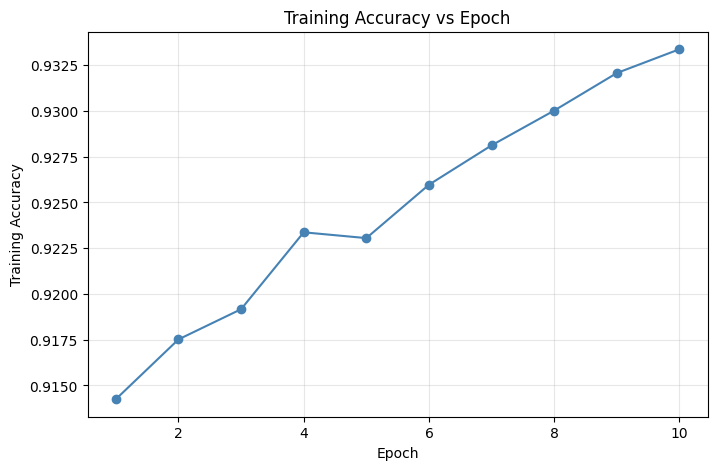

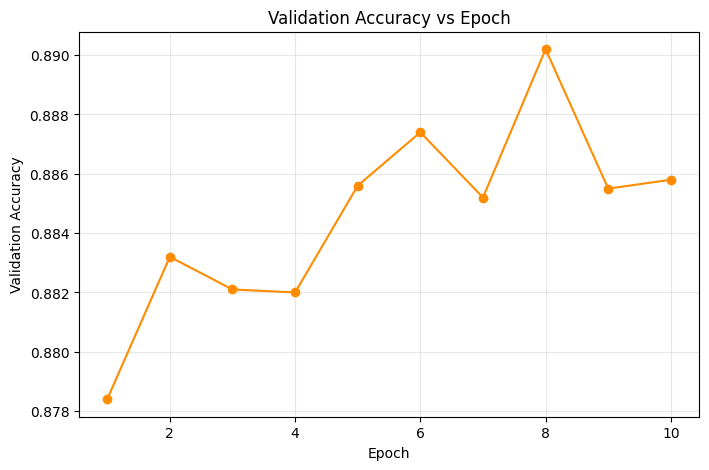

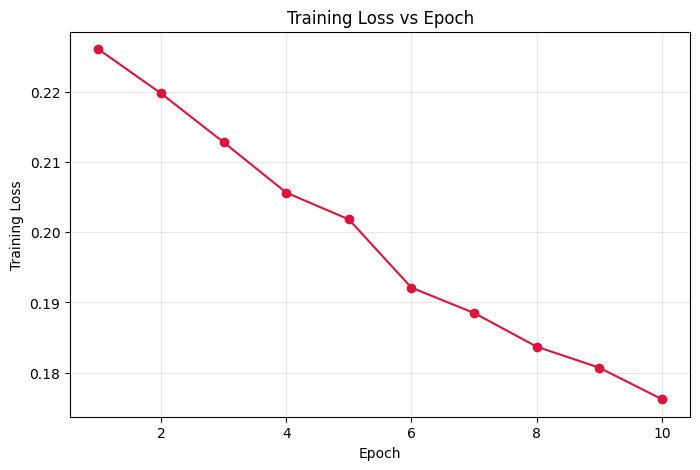

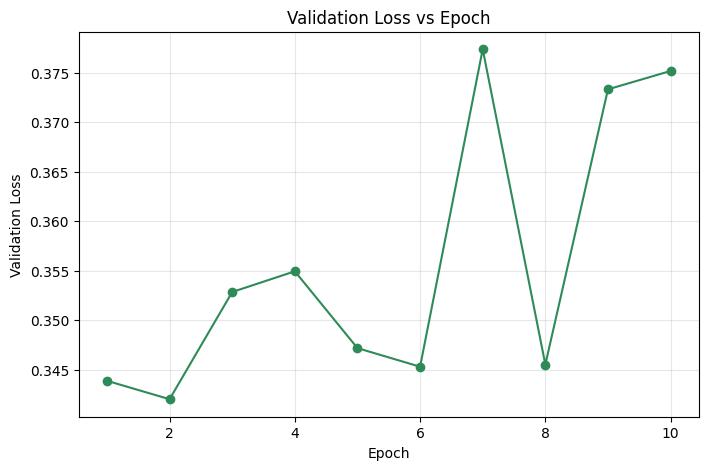

In [ ]:
import matplotlib.pyplot as plt
h = baseline_history.history
epochs_range = range(1, len(h['accuracy']) + 1)

# ---- Plot 3: Training Accuracy vs Epoch ----
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, h['accuracy'], marker='o', color='steelblue')
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

# ---- Plot 4: Validation Accuracy vs Epoch ----
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, h['val_accuracy'], marker='o', color='darkorange')
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

# ---- Plot 5: Training Loss vs Epoch ----
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, h['loss'], marker='o', color='crimson')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

# ---- Plot 6: Validation Loss vs Epoch ----
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, h['val_loss'], marker='o', color='seagreen')
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True, alpha=0.3)
plt.show()

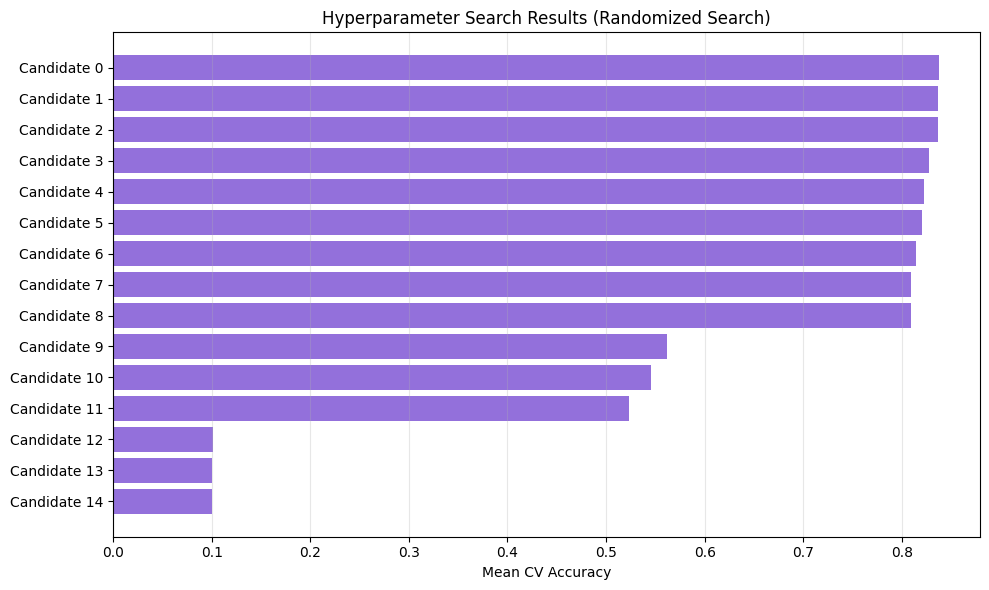

Top 5 Candidates
----------------------------------------
 mean_test_score                                                                                                                                                                                                          params
        0.837500      {'model__optimizer_name': 'rmsprop', 'model__n_neurons': 32, 'model__n_hidden': 3, 'model__learning_rate': 0.001, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}
        0.837000 {'model__optimizer_name': 'rmsprop', 'model__n_neurons': 128, 'model__n_hidden': 1, 'model__learning_rate': 0.001, 'model__dropout_rate': 0.5, 'model__activation': 'sigmoid', 'epochs': 30, 'batch_size': 128}
        0.836500        {'model__optimizer_name': 'adam', 'model__n_neurons': 256, 'model__n_hidden': 3, 'model__learning_rate': 0.001, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 32}
        0.827500           {'model__optimi

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract results from RandomizedSearchCV
results_df = pd.DataFrame(random_search_result.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(range(len(results_df)), results_df['mean_test_score'], color='mediumpurple')
plt.yticks(range(len(results_df)), [f"Candidate {i}" for i in range(len(results_df))])
plt.xlabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results (Randomized Search)")
plt.gca().invert_yaxis()  # highest score on top
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 Candidates")
print("-" * 40)
print(results_df[['mean_test_score', 'params']].head(5).to_string(index=False))